In [5]:
from pathlib import Path
import json
from dataclasses import asdict
from itertools import product

from rabl.machine_learning.tuner import GridSearchConfig, TrialResult, count_grid_combinations
from rabl.machine_learning.lstm_pipeline import (
    build_datasets,
    train_with_fallback,
    cleanup_cuda,
)

In [7]:
lookback_datasets = {
    12: Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k12_minmax_train0.70_val0.15_test0.15.h5"),
    #8:  Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k8_minmax_train0.70_val0.15_test0.15.h5"),
    #4:  Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k4_minmax_train0.70_val0.15_test0.15.h5"),
}

for lb, p in lookback_datasets.items():
    print(f"lookback={lb} exists={p.exists()} path={p}")

lookback=12 exists=True path=..\outputs\datasets\scaled_split\lstm_merged_batches_0001-0002_k12_minmax_train0.70_val0.15_test0.15.h5


In [11]:
out_dir = Path("../outputs/ml_results/tuning_test2")
out_dir.mkdir(parents=True, exist_ok=True)

config = GridSearchConfig(
    lookback_datasets=lookback_datasets,
    learning_rates=[1e-4],
    batch_sizes=[256],
    n_lstm_values=[1],
    hidden_lstm_values=[256],
    hidden_fc_values=[256],
    n_fc=1,
    epochs=50,
    seed=123,
    out_dir=out_dir,
    prefer_gpu=True,
    verbose=1,
    lstm_dropout=0.3,
    preload_train_to_device=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-6,
    restore_best_weights=True,
    step_lr_step_size=30,
    step_lr_gamma=0.5,
)

print("out_dir:", config.out_dir)
print("Total trials:", count_grid_combinations(config))

out_dir: ..\outputs\ml_results\tuning_test2
Total trials: 1


Total combinations: 1
[1/1] lookback=12, lr=0.0001, batch_size=256, n_lstm=2, hidden_lstm=256, hidden_fc=256
Using GPU: NVIDIA GeForce RTX 4060 Ti

Deterministic seed set to: 123
LSTMRegressor architecture:
  Input features: 14
  LSTM layers (2): hidden_size=256, dropout=0.3
  FC layers (1): [256]
  Output targets: 13



Preloading train batches: 10943batch [00:29, 369.20batch/s]


Preloaded 10943 training batches to cuda:0 in 29.64s.


Train 1/50: 100%|██████████████████████████████████████████| 10943/10943 [00:39<00:00, 278.57batch/s, loss=0.000053274]
Val 1/50: 2345batch [00:08, 268.86batch/s]


Epoch 1/50 - loss: 0.000985351 - val_loss: 0.000072505 - lr: 1.000e-04 - data_wait: 0.17s - h2d: 0.00s - compute: 34.11s - val_time: 8.72s - preloaded: True - preload_time: 29.64s - max_cuda_mem: 2230.77 MB


...

Epoch 11/50 - loss: 0.000007576 - val_loss: 0.000017861 - lr: 1.000e-04 - data_wait: 0.18s - h2d: 0.00s - compute: 34.62s - val_time: 8.79s - preloaded: True - preload_time: 29.64s - max_cuda_mem: 2230.77 MB
Early stopping check: 8/10 epochs without validation improvement.


Train 12/50: 100%|█████████████████████████████████████████| 10943/10943 [00:39<00:00, 275.66batch/s, loss=0.000006961]
Val 12/50: 2345batch [00:08, 275.27batch/s]


Epoch 12/50 - loss: 0.000007320 - val_loss: 0.000012747 - lr: 1.000e-04 - data_wait: 0.17s - h2d: 0.00s - compute: 34.49s - val_time: 8.52s - preloaded: True - preload_time: 29.64s - max_cuda_mem: 2230.77 MB
Early stopping check: 9/10 epochs without validation improvement.


Train 13/50: 100%|█████████████████████████████████████████| 10943/10943 [00:39<00:00, 279.80batch/s, loss=0.000007119]
Val 13/50: 2345batch [00:08, 269.26batch/s]


Epoch 13/50 - loss: 0.000007178 - val_loss: 0.000011485 - lr: 1.000e-04 - data_wait: 0.17s - h2d: 0.00s - compute: 33.98s - val_time: 8.71s - preloaded: True - preload_time: 29.64s - max_cuda_mem: 2230.77 MB
Early stopping check: 10/10 epochs without validation improvement.
Early stopping triggered at epoch 13; best validation loss was 0.000012315 at epoch 3.
Restored best model weights from epoch 3.
Saved training curves to ..\outputs\ml_results\tuning_test2\trial_0001_lb12_lr0.0001_bs256_nl2_hl256_hf256\lstm_train_val_curve.png
Saved learning-rate curve to ..\outputs\ml_results\tuning_test2\trial_0001_lb12_lr0.0001_bs256_nl2_hl256_hf256\lstm_lr_curve.png

Timing summary (cumulative):
  preload_time: 29.64s
  train_data_wait_time: 2.22s
  train_h2d_time: 0.02s
  train_compute_time: 440.65s
  train_epoch_time_total: 442.89s
  val_time_total: 111.31s
  estimated_total_time: 583.84s

Best trial:
{
  "lookback": 12,
  "dataset_path": "..\\outputs\\datasets\\scaled_split\\lstm_merged_batch

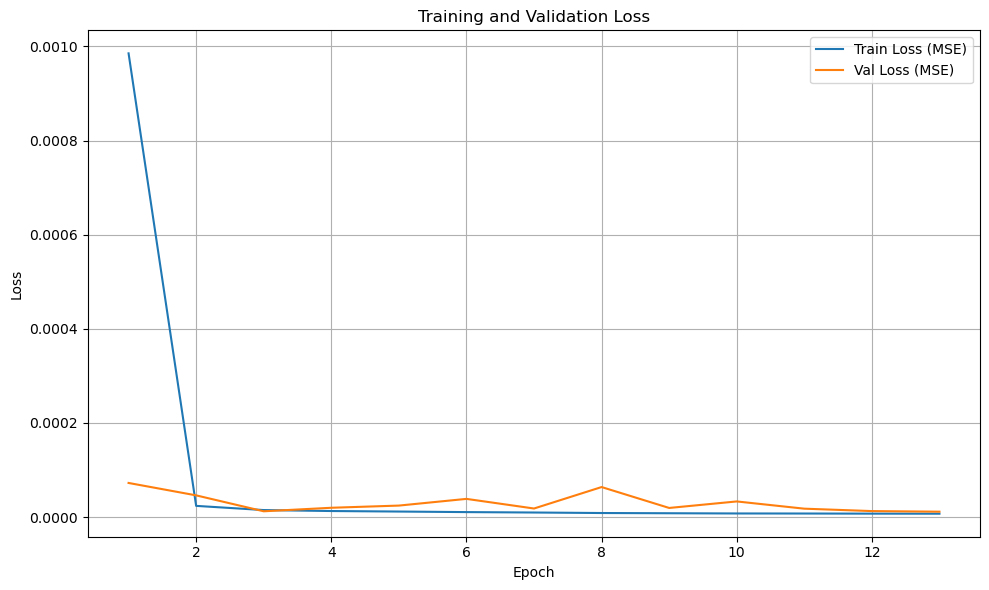

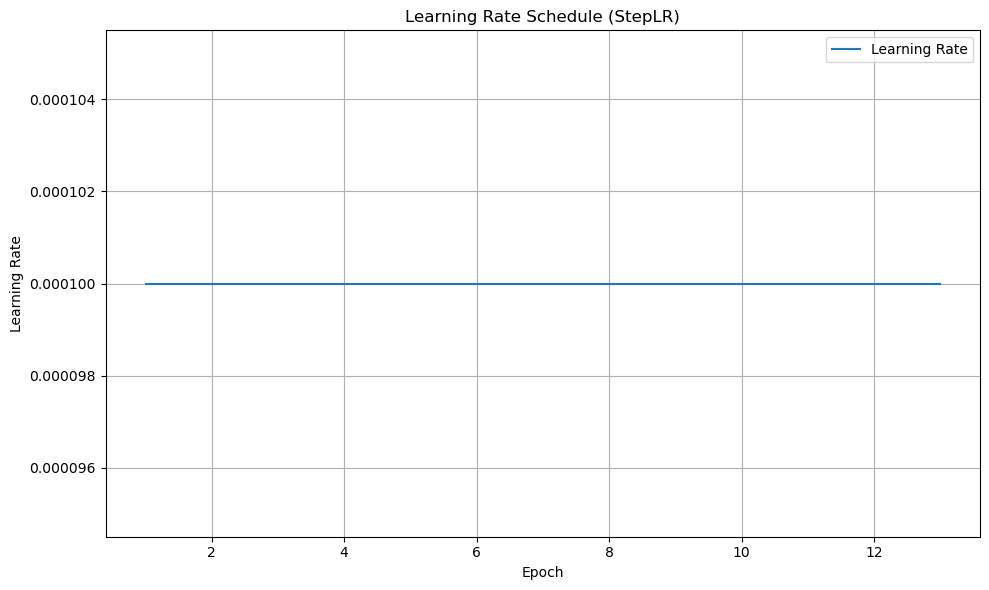

In [13]:
from rabl.machine_learning.tuner import run_grid_search

results, best = run_grid_search(config)

print("Best trial:", best)